In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier



In [ ]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

#cargar datos
df = pd.read_csv("/content/drive/MyDrive/LABS/ExamenFinal/creditos_andesbank.csv")
df.head()

Mounted at /content/drive


,edad,ingreso_mensual,monto_desembolsado,tasa_anual_pct,plazo_meses,cuota_ingreso_ratio,antiguedad_cliente_meses,num_productos_vigentes,num_creditos_otros_bancos,penalidad_precancelacion_cobrada,cancelacion_anticipada
0,59,4147,23144,20.9,36,0.194,61,1,1,0.0,0
1,34,5352,23277,15.2,60,0.091,69,4,1,0.0,0
2,30,7179,53140,22.0,24,0.386,39,4,1,0.0,0
3,37,5248,8144,18.2,24,0.081,29,2,0,0.0,0
4,29,5182,27988,20.3,18,0.375,19,2,1,0.0,0


Desarrollo requerido

pregunta 1:


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   edad                              1800 non-null   int64  
 1   ingreso_mensual                   1800 non-null   int64  
 2   monto_desembolsado                1800 non-null   int64  
 3   tasa_anual_pct                    1800 non-null   float64
 4   plazo_meses                       1800 non-null   int64  
 5   cuota_ingreso_ratio               1800 non-null   float64
 6   antiguedad_cliente_meses          1800 non-null   int64  
 7   num_productos_vigentes            1800 non-null   int64  
 8   num_creditos_otros_bancos         1800 non-null   int64  
 9   penalidad_precancelacion_cobrada  1800 non-null   float64
 10  cancelacion_anticipada            1800 non-null   int64  
dtypes: float64(3), int64(8)
memory usage: 154.8 KB


In [ ]:
df["cancelacion_anticipada"].value_counts()

,count
cancelacion_anticipada,
0,961
1,839


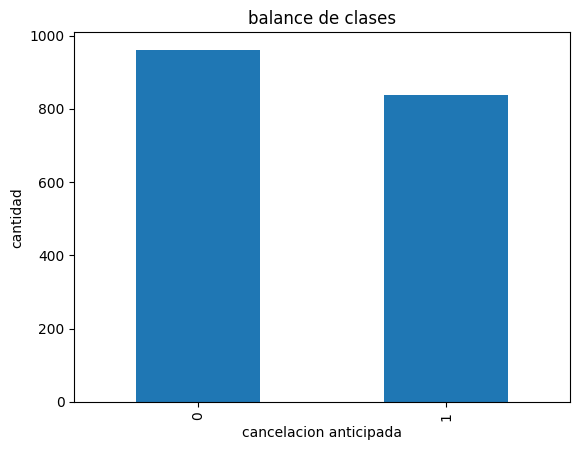

In [ ]:
df["cancelacion_anticipada"].value_counts().plot(kind="bar")
plt.title("balance de clases")
plt.xlabel("cancelacion anticipada")
plt.ylabel("cantidad")
plt.show()

In [ ]:
x=df.drop(columns=["cancelacion_anticipada"])
y=df["cancelacion_anticipada"]

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

cancelacion_anticipada
0    0.534028
1    0.465972
Name: proportion, dtype: float64
cancelacion_anticipada
0    0.533333
1    0.466667
Name: proportion, dtype: float64


Segundo desarrollo requerido


In [ ]:
#baseline con dummpy
dummy=DummyClassifier(strategy="most_frequent",random_state=42)
dummy.fit(x_train, y_train)
y_pred=dummy.predict(x_test)

In [ ]:
#calcular el accuracy
accuracy_dummy=accuracy_score(y_test, y_pred)
print("accuracy_dummy",accuracy_dummy)

print("accuracy dummyclassifier:{:.4f}".format(accuracy_dummy))

accuracy_dummy 0.5333333333333333
accuracy dummyclassifier:0.5333


Desarrollo 3

In [ ]:
#validacion cruzada
cv= StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
modelos={
    "regresion_logistica": LogisticRegression(max_iter=1000, random_state=42),"arbol de decision":DecisionTreeClassifier(random_state=42),"Random Forest":RandomForestClassifier(random_state=42)}
#modelos para el benchmarking

In [ ]:
#metricas de evaluacion
metricas={"accuracy":"accuracy", "precision":"precision", "recall":"recall", "f1":"f1","roc_auc":"roc_auc"}

In [ ]:
#lista para guardar los resultados
resultados=[]

for nombre,modelo in modelos.items():
  scores=cross_validate(modelo,x_train,y_train,cv=cv,scoring=metricas)
  resultados.append({"Modelo": nombre, "accuracy": scores["test_accuracy"].mean(),"precision": scores["test_precision"].mean(),"recall": scores["test_recall"].mean(),"f1": scores["test_f1"].mean(),"roc_auc": scores["test_roc_auc"].mean()})

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

In [ ]:
#tabla comparativa
tabla_benchmark=pd.DataFrame(resultados)
tabla_benchmark


,Modelo,accuracy,precision,recall,f1,roc_auc
0,regresion_logistica,0.928472,0.996580,0.849508,0.917055,0.956621
1,arbol de decision,0.880556,0.869323,0.876329,0.872444,0.880309
2,Random Forest,0.927778,0.993158,0.850989,0.916465,0.953437


In [ ]:
#ordenar los modelos segun recall
tabla_benchmark=tabla_benchmark.sort_values(by="recall",ascending=False)
tabla_benchmark

,Modelo,accuracy,precision,recall,f1,roc_auc
1,arbol de decision,0.880556,0.869323,0.876329,0.872444,0.880309
2,Random Forest,0.927778,0.993158,0.850989,0.916465,0.953437
0,regresion_logistica,0.928472,0.996580,0.849508,0.917055,0.956621


In [ ]:
tabla_benchmark.round(4)

,Modelo,accuracy,precision,recall,f1,roc_auc
1,arbol de decision,0.8806,0.8693,0.8763,0.8724,0.8803
2,Random Forest,0.9278,0.9932,0.8510,0.9165,0.9534
0,regresion_logistica,0.9285,0.9966,0.8495,0.9171,0.9566


In [ ]:
#modelo candidato segun el mayor recall
candidato=tabla_benchmark.iloc[0]["Modelo"]
print("modelo candidato",candidato)

modelo candidato arbol de decision


Desarrollo 4

In [ ]:
from sklearn.model_selection import GridSearchCV
parametros_rf={"n_estimators":[100,200],"max_depth":[5,10,None],"min_samples_split":[2,5]}

grid_rf=GridSearchCV(RandomForestClassifier(random_state=42),param_grid=parametros_rf,cv=cv,scoring="recall",n_jobs=1)
grid_rf.fit(x_train,y_train)
print("mejores parametros RF:", grid_rf.best_params_)
print("mejor recall cv:", grid_rf.best_score_)

mejores parametros RF: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
mejor recall cv: 0.8524930901050304


In [ ]:
parametros_dt={"max_depth":[3,5,10,None],"min_samples_split":[2,5,10],"criterion":["gini", "entropy"]}

grid_dt=GridSearchCV(DecisionTreeClassifier(random_state=42),param_grid=parametros_dt,cv=cv,scoring="recall",n_jobs=1)

grid_dt.fit(x_train,y_train)
print("mejores parametros DT:", grid_dt.best_params_)
print("mejor recall cv:", grid_dt.best_score_)

mejores parametros DT: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 5}
mejor recall cv: 0.8778220011055833


In [ ]:
if grid_rf.best_score_>grid_dt.best_score_:
  modelo_final=grid_rf.best_estimator_
  print("Ganador:Random forest")
else:
  modelo_final=grid_dt.best_estimator_
  print("Ganador:Decision Tree")

Ganador:Decision Tree


Desarrollo 5

In [ ]:
#importancia de variables
importancia=pd.DataFrame({"variable":x_train.columns,"importancia":modelo_final.feature_importances_})
importancia=importancia.sort_values(by="importancia",ascending=False)
importancia

,variable,importancia
9,penalidad_precancelacion_cobrada,0.780823
1,ingreso_mensual,0.047680
2,monto_desembolsado,0.033818
0,edad,0.033582
3,tasa_anual_pct,0.030205
6,antiguedad_cliente_meses,0.028198
4,plazo_meses,0.015692
8,num_creditos_otros_bancos,0.014193
7,num_productos_vigentes,0.008189
5,cuota_ingreso_ratio,0.007620


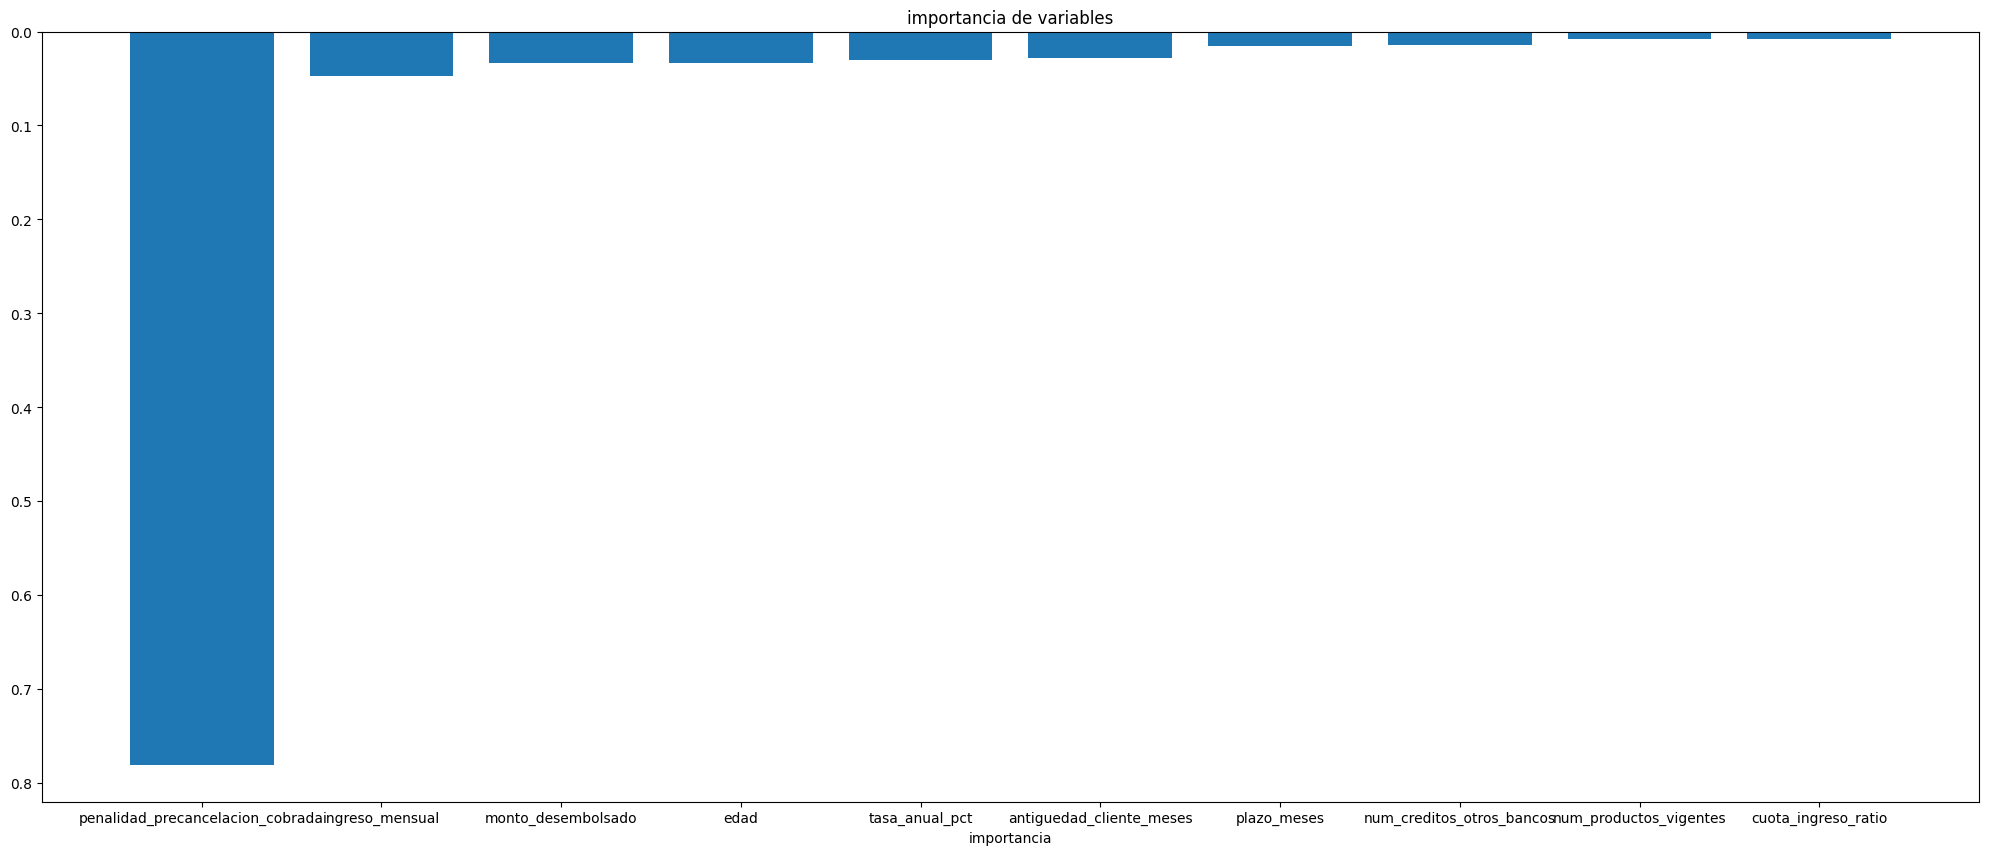

In [ ]:
#graficar la importancia
plt.figure(figsize=(25,10))
plt.bar(importancia["variable"],importancia["importancia"])
plt.gca().invert_yaxis()
plt.title("importancia de variables")
plt.xlabel("importancia")

plt.show()

Desarrollo 6

In [ ]:
#clasficacion
y_pred=modelo_final.predict(x_test)

#librerias
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

#clasificacion report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.90      0.89      0.90       192
           1       0.88      0.89      0.88       168

    accuracy                           0.89       360
   macro avg       0.89      0.89      0.89       360
weighted avg       0.89      0.89      0.89       360



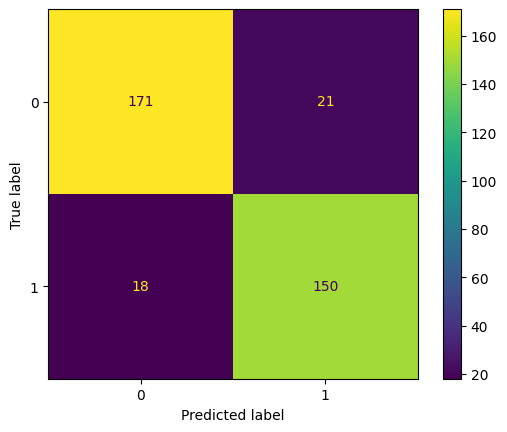

In [ ]:
#matriz de confusion
cm=confusion_matrix(y_test,y_pred)
disp= ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.show()

In [ ]:
#costos del negocio
tn,fp,fn,tp=confusion_matrix(y_test,y_pred).ravel()
print("tn",tn)
print("fp",fp)
print("fn",fn)
print("tp",tp)

tn 171
fp 21
fn 18
tp 150


PREGUNTAS DE DECISION

1.- SE DEBE PRIORIZAR EL RECALL, YA QUE ES MAS IMPORTANTE DE DETECTAR LA MAYOR CANTIDAD DE CREDITOS QUE SERAN CANCELADOS ANTICIPADAMENTE Y EVITAR PEDIDAS POR FALSOS NEGATIVOS

2.-EL DATASET ESTA RELATIVAMENTE BALANCEADO CLASE 0 Y CLASE 1. EL DUMMYCLASSIFIER OBTUVO UN ACCURACY DE 53.33% SIRVIENDO UNICAMENTE COMO LINEA BASE

3.- SE REALIZO GRIDSEARCHCV PARA EVALUAR TODAS LAS COMBINACIONES DE HIPERPARAMETROS. EL ARBOL DE DECISION GANO CON UN RECALL CV DE 0.8778 SUPERANDO AL RANDOM FOREST

4.-LA VARIABLE MAS IMPORTANTE FUE PENALIDAD_PRECANCELACION_COBRADA, SEGUIDA POR INGRESO_MENSUAL Y MONTO_DESEMBOLSADO. ESTOS RESULTADOS TIENEN SENTIDO PORQUE INFLUYEN DIRECTAMENTE EN LA DECISION DE CANCELAR ANTICIPADAMENTE UN CREDITO.

5.- EL MODELO OBTUVO 21 FALSOS POSITIVOS Y 18 FALSOS NEGATIVOS CON UN COSTO DE 8K Y MAS. SI IMPLEMENTARIA EL MODELO, YA QUE OBTUVO 89% DE ACCURACY Y RECALL AUNQUE DEBE MONITOREARSE PARA REDUCIR FALSOS NEGATIVOS